# Q2 — MLP on MNIST
### AI Operations (DA3408) — Assignment 1 | Question 2

**Steps:**

0. Connect to the tracking server and import the instrumented trainer.
1. Load MNIST once so every run sees the identical train/validation split.
2. Fix the sweep grid: `learning_rate` × `batch_size`, everything else held constant.
3. Run the sweep — one MLflow run per combination, logged by `train.run_experiment()`.
4. Pull all runs back with `mlflow.search_runs()` and export the comparison table.
5. Plot `train_loss` and `val_accuracy` against epoch for the best and worst run.
6. Quantify which hyperparameter has the larger effect.
7. Confirm the ranking in the MLflow UI **Compare** view.

**Deliverables:** the instrumented `train.py`, the comparison table (`results/runs.csv`), the
best-vs-worst curve plots, a screenshot of the Compare view, and a 150–250 word written analysis.

> **Prerequisite:** a local MLflow Tracking Server must already be running, started **from this
> directory** so the store lands next to the notebook:
> ```bash
> cd q2_mlflow_mnist
> mlflow server --backend-store-uri sqlite:///mlflow.db \
>     --default-artifact-root ./mlruns --host 0.0.0.0 --port 5000 --allowed-hosts "*"
> ```
> Run that command in a separate terminal *before* executing the cells below, then leave it running.

## Step 0 — Setup

In [1]:
import matplotlib.pyplot as plt
import mlflow
import pandas as pd
from IPython.display import display
from mlflow.tracking import MlflowClient

from train import load_mnist, run_experiment

%matplotlib inline

TRACKING_URI = "http://localhost:5000"
EXPERIMENT_NAME = "mnist-mlp"

mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient()

print("tracking URI      :", mlflow.get_tracking_uri())
print("matplotlib backend:", plt.get_backend(), "(must NOT be 'agg')")

tracking URI      : http://localhost:5000
matplotlib backend: inline (must NOT be 'agg')


## Step 1 — Load MNIST once

In [2]:
data = load_mnist(10000, 42)
X_train, X_val, y_train, y_val = data

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)

X_train: (10000, 784)
X_val  : (2000, 784)
y_train: (10000,)
y_val  : (2000,)


## Step 2 — The sweep grid


| Hyperparameter | Values swept |
| --- | --- |
| `learning_rate` | 0.001, 0.01, 0.1 |
| `batch_size` | 32, 256 |

Held constant:

| Held constant | Value |
| --- | --- |
| `hidden_size` | 128 |
| `epochs` | 30 |
| `n_train` | 10000 |
| `seed` | 42 |
| solver | `adam` |
| validation set | 2000 samples (same split for every run) |

## Step 3 — Run the sweep

In [3]:
%%time

LEARNING_RATES = [0.001, 0.01, 0.1]
BATCH_SIZES = [32, 256]

results = []

for lr in LEARNING_RATES:
    for bs in BATCH_SIZES:
        print(f"→ starting learning_rate={lr}, batch_size={bs} ...", flush=True)
        run_id, val_acc = run_experiment(
            learning_rate=lr,
            batch_size=bs,
            hidden_size=128,
            epochs=30,
            n_train=10000,
            seed=42,
            data=data,
        )
        results.append((lr, bs, run_id, val_acc))
        print(
            f"✓ done   learning_rate={lr}, batch_size={bs} → "
            f"final_val_accuracy={val_acc:.4f}  (run_id={run_id})\n",
            flush=True,
        )

print(f"Sweep complete: {len(results)} runs logged to {EXPERIMENT_NAME!r}")

→ starting learning_rate=0.001, batch_size=32 ...


2026/08/30 12:26:23 INFO mlflow.tracking.fluent: Experiment with name 'mnist-mlp' does not exist. Creating a new experiment.


epoch   1/30  train_loss=0.5410  train_acc=0.9289  val_acc=0.9080
epoch   2/30  train_loss=0.2571  train_acc=0.9483  val_acc=0.9305
epoch   3/30  train_loss=0.1897  train_acc=0.9626  val_acc=0.9405
epoch   4/30  train_loss=0.1448  train_acc=0.9730  val_acc=0.9430
epoch   5/30  train_loss=0.1121  train_acc=0.9824  val_acc=0.9450
epoch   6/30  train_loss=0.0873  train_acc=0.9856  val_acc=0.9445
epoch   7/30  train_loss=0.0678  train_acc=0.9894  val_acc=0.9475
epoch   8/30  train_loss=0.0523  train_acc=0.9924  val_acc=0.9470
epoch   9/30  train_loss=0.0397  train_acc=0.9937  val_acc=0.9485
epoch  10/30  train_loss=0.0302  train_acc=0.9946  val_acc=0.9490
epoch  11/30  train_loss=0.0233  train_acc=0.9950  val_acc=0.9490
epoch  12/30  train_loss=0.0188  train_acc=0.9943  val_acc=0.9455
epoch  13/30  train_loss=0.0149  train_acc=0.9956  val_acc=0.9485
epoch  14/30  train_loss=0.0140  train_acc=0.9967  val_acc=0.9445
epoch  15/30  train_loss=0.0139  train_acc=0.9962  val_acc=0.9490
epoch  16/

## Step 4 — Compare the runs with `mlflow.search_runs()`

In [4]:
runs_raw = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=["metrics.final_val_accuracy DESC"],
)

WANTED = [
    "run_id",
    "tags.mlflow.runName",
    "params.learning_rate",
    "params.batch_size",
    "metrics.final_train_loss",
    "metrics.final_val_accuracy",
    "metrics.best_val_accuracy",
    "metrics.overfit_gap",
]
columns = [c for c in WANTED if c in runs_raw.columns]
missing = [c for c in WANTED if c not in runs_raw.columns]
if missing:
    print("note — columns absent from the search result:", missing)

runs_table = runs_raw[columns].reset_index(drop=True)

display(runs_table)

runs_table.to_csv("results/runs.csv", index=False)
print(f"\nWrote results/runs.csv  ({len(runs_table)} rows)")

,run_id,tags.mlflow.runName,params.learning_rate,params.batch_size,metrics.final_train_loss,metrics.final_val_accuracy,metrics.best_val_accuracy,metrics.overfit_gap
0,0d06c4798b6a41c99d9916b6abd6ac9e,mlp-lr0.001-bs32,0.001,32,0.005303,0.9525,0.9545,0.0463
1,62e8d6c6366944a492c8e4a266091002,mlp-lr0.001-bs256,0.001,256,0.023113,0.9470,0.9470,0.0492
2,c32937bbdaec4c0b8805bbc0b298f7dd,mlp-lr0.01-bs256,0.01,256,0.028781,0.9465,0.9530,0.0440
3,0909f73682d94225b49d1f1d801e5008,mlp-lr0.01-bs32,0.01,32,0.093162,0.9275,0.9420,0.0466
4,745812b656844d36867c23062a3a77ca,mlp-lr0.1-bs256,0.1,256,0.538711,0.8160,0.8795,0.0244
5,17b31b71d2c64296900f1d3bf60cab30,mlp-lr0.1-bs32,0.1,32,1.087633,0.6900,0.8010,0.0136



Wrote results/runs.csv  (6 rows)


## Step 5 — Best vs worst: `train_loss` and `val_accuracy`

In [5]:
def fetch_curve(run_id, metric):
    points = sorted(client.get_metric_history(run_id, metric), key=lambda m: m.step)
    return [m.step + 1 for m in points], [m.value for m in points]


def plot_run_curves(ax_loss, ax_acc, run_id, loss_ylim=None, acc_ylim=None):
    epochs, loss = fetch_curve(run_id, "train_loss")
    _, val_acc = fetch_curve(run_id, "val_accuracy")

    ax_loss.plot(epochs, loss, color="tab:red", label="train_loss")
    ax_loss.set_title("train_loss vs epoch")
    ax_loss.set_xlabel("epoch")
    ax_loss.set_ylabel("train_loss")

    ax_acc.plot(epochs, val_acc, color="tab:blue", label="val_accuracy")
    ax_acc.set_title("val_accuracy vs epoch")
    ax_acc.set_xlabel("epoch")
    ax_acc.set_ylabel("val_accuracy")

    if loss_ylim:
        ax_loss.set_ylim(*loss_ylim)
    if acc_ylim:
        ax_acc.set_ylim(*acc_ylim)

    for ax in (ax_loss, ax_acc):
        ax.grid(alpha=0.3)
        ax.legend(loc="best")


def shared_limits(run_ids):
    losses, accs = [], []
    for run_id in run_ids:
        losses += fetch_curve(run_id, "train_loss")[1]
        accs += fetch_curve(run_id, "val_accuracy")[1]
    pad_l = 0.05 * (max(losses) - min(losses) or 1)
    pad_a = 0.05 * (max(accs) - min(accs) or 1)
    return (min(losses) - pad_l, max(losses) + pad_l), (min(accs) - pad_a, max(accs) + pad_a)


best = runs_table.iloc[0]
worst = runs_table.iloc[-1]
if best["run_id"] == worst["run_id"]:
    print("WARNING: only one run in the table — the BEST and WORST figures will show the same run.")

LOSS_YLIM, ACC_YLIM = shared_limits([best["run_id"], worst["run_id"]])

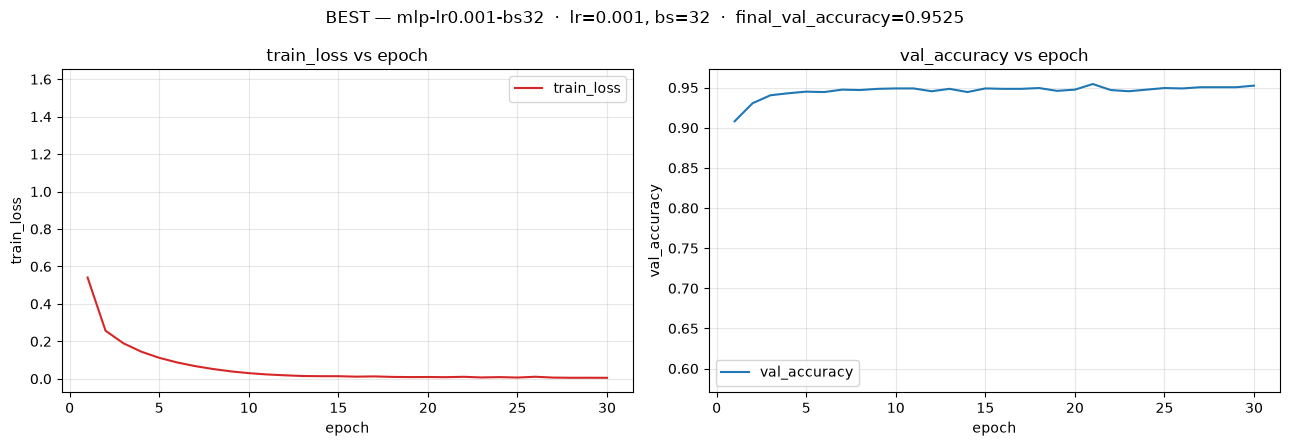

In [6]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 4.5))
plot_run_curves(ax_loss, ax_acc, best["run_id"], LOSS_YLIM, ACC_YLIM)
fig.suptitle(
    f"BEST — {best.get('tags.mlflow.runName', best['run_id'])}"
    f"  ·  lr={best['params.learning_rate']}, bs={best['params.batch_size']}"
    f"  ·  final_val_accuracy={float(best['metrics.final_val_accuracy']):.4f}"
)
fig.tight_layout()
plt.show()

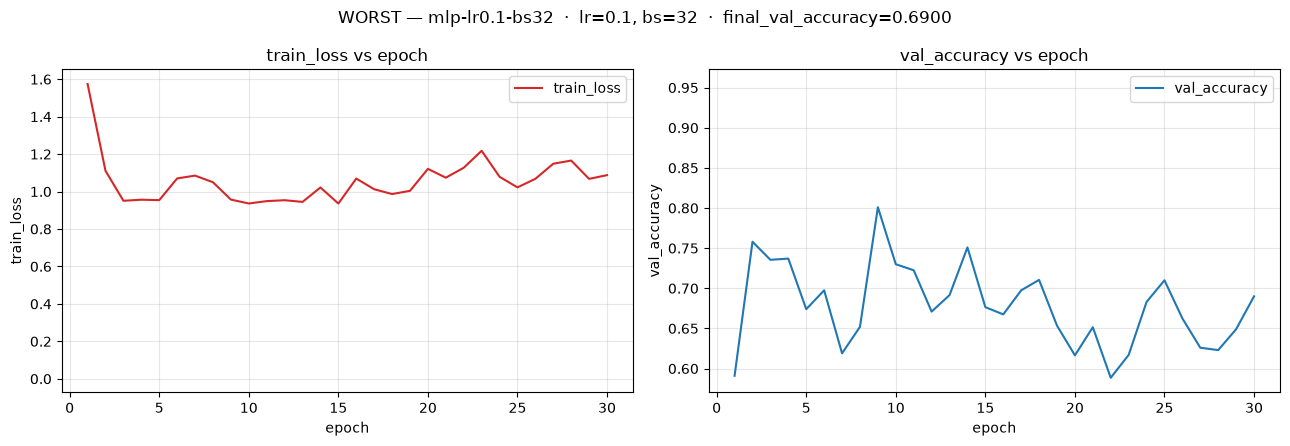

In [7]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 4.5))
plot_run_curves(ax_loss, ax_acc, worst["run_id"], LOSS_YLIM, ACC_YLIM)
fig.suptitle(
    f"WORST — {worst.get('tags.mlflow.runName', worst['run_id'])}"
    f"  ·  lr={worst['params.learning_rate']}, bs={worst['params.batch_size']}"
    f"  ·  final_val_accuracy={float(worst['metrics.final_val_accuracy']):.4f}"
)
fig.tight_layout()
plt.show()

## Step 6 — Which hyperparameter has the larger effect?

In [8]:
table = runs_table.assign(
    lr=runs_table["params.learning_rate"].astype(float),
    bs=runs_table["params.batch_size"].astype(int),
    acc=runs_table["metrics.final_val_accuracy"].astype(float),
)

lr_effect = table["acc"].max() - table["acc"].min()

pair_diffs = {}
for lr_value, group in table.groupby("lr"):
    if len(group) == 2:
        pair_diffs[lr_value] = abs(group["acc"].iloc[0] - group["acc"].iloc[1])
    else:
        print(f"note — learning_rate={lr_value} has {len(group)} run(s), not a pair; skipped")

bs_effect = sum(pair_diffs.values()) / len(pair_diffs) if pair_diffs else float("nan")

print("EFFECT SIZES (final_val_accuracy)")
print("─" * 52)
print(f"learning-rate effect  (max - min over all runs) : {lr_effect:.4f}")
print(f"batch-size effect     (mean |Δ| within lr pairs): {bs_effect:.4f}")
for lr_value, diff in sorted(pair_diffs.items()):
    print(f"    lr={lr_value:<6} |acc(bs=32) - acc(bs=256)| = {diff:.4f}")
print("─" * 52)
if lr_effect > bs_effect:
    print(f"→ LEARNING RATE has the larger effect ({lr_effect:.4f} vs {bs_effect:.4f}, "
          f"{lr_effect / bs_effect:.1f}x)" if bs_effect else "→ LEARNING RATE has the larger effect")
else:
    print(f"→ BATCH SIZE has the larger effect ({bs_effect:.4f} vs {lr_effect:.4f})")

print(f"\nBest run : lr={best['params.learning_rate']}, bs={best['params.batch_size']}, "
      f"final_val_accuracy={float(best['metrics.final_val_accuracy']):.4f}, "
      f"overfit_gap={float(best['metrics.overfit_gap']):.4f}")
print(f"Worst run: lr={worst['params.learning_rate']}, bs={worst['params.batch_size']}, "
      f"final_val_accuracy={float(worst['metrics.final_val_accuracy']):.4f}, "
      f"overfit_gap={float(worst['metrics.overfit_gap']):.4f}")

EFFECT SIZES (final_val_accuracy)
────────────────────────────────────────────────────
learning-rate effect  (max - min over all runs) : 0.2625
batch-size effect     (mean |Δ| within lr pairs): 0.0502
    lr=0.001  |acc(bs=32) - acc(bs=256)| = 0.0055
    lr=0.01   |acc(bs=32) - acc(bs=256)| = 0.0190
    lr=0.1    |acc(bs=32) - acc(bs=256)| = 0.1260
────────────────────────────────────────────────────
→ LEARNING RATE has the larger effect (0.2625 vs 0.0502, 5.2x)

Best run : lr=0.001, bs=32, final_val_accuracy=0.9525, overfit_gap=0.0463
Worst run: lr=0.1, bs=32, final_val_accuracy=0.6900, overfit_gap=0.0136


## Step 7 — Confirm in the MLflow UI
1. Go to **http://localhost:5000** in your browser.
2. Open the **mnist-mlp** experiment.
3. Select all 6 runs (checkboxes on the left) and click **Compare**.
4. Check that the run the UI ranks highest matches the best run from Step 4, and use the parallel
   coordinates plot to confirm the learning-rate effect.
5. Save the screenshot to `results/`.

---
### ✅ Deliverables
- [ ] `train.py` instrumented with params, per-epoch metrics, figure and model logging
- [ ] 6 runs logged to the `mnist-mlp` experiment
- [ ] Comparison table exported to `results/runs.csv`
- [ ] Best-vs-worst `train_loss` / `val_accuracy` plots
- [ ] Screenshot of the 6-run **Compare** view in the MLflow UI, saved under `screenshots/`